In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from aeon.visualisation import plot_critical_difference
import pandas as pd

SAVE_FIGURES = False

def load_npz(path):
    data = np.load(path)
    return {k: data[k] for k in data.files}

In [2]:
FIGSIZE = (8, 5)
FONTSIZE = 14
FONTSIZE_TITLE = 17

In [3]:
# models are evaluated at different epochs, so we specify the epoch to load here
LOAD_EPOCH=18

In [4]:
dic_model_colors = {
    "Causal RevIN":          "#FF7F00",  # vivid orange
    "Causal RevIN + asinh":  "#573030FF",  # semi-transparent brown
    "RevIN":                 "#00CC66",  # vivid green
    "RevIN + asinh":         "#0055FF",  # electric deep blue
    "Prefix@4 RevIN":              "#FF3300",  # bright red-orange
    "Prefix@4 RevIN + asinh":      "#CC0099",  # strong magenta
}

dic_model_symbols = {
    "Causal RevIN":          "o",   # circle
    "Causal RevIN + asinh":  "x",   # cross
    "RevIN":                 "s",   # square
    "RevIN + asinh":         "d",   # diamond
    "Prefix@4 RevIN":              "^",   # triangle up
    "Prefix@4 RevIN + asinh":      "v",   # triangle down
}

# Ranks per context length

In [5]:
CTX_LEN=1024
assert CTX_LEN in [64, 128, 256, 512, 1024]

In [6]:
metrics_causal_gift_eval = load_npz(f"results/{LOAD_EPOCH}/causal/{CTX_LEN}.npz")
metrics_causal_asinh_gift_eval = load_npz(f"results/{LOAD_EPOCH}/causalsinh/{CTX_LEN}.npz")
metrics_asinh_gift_eval = load_npz(f"results/{LOAD_EPOCH}/vanillasinh/{CTX_LEN}.npz")
metrics_gift_eval = load_npz(f"results/{LOAD_EPOCH}/vanilla/{CTX_LEN}.npz")
metrics_Prefix_gift_eval = load_npz(f"results/{LOAD_EPOCH}/prefix8/{CTX_LEN}.npz")
metrics_Prefix_asinh_gift_eval = load_npz(f"results/{LOAD_EPOCH}/prefix8sinh/{CTX_LEN}.npz")

# Critical Rank Diagram

## Aggregated by forecast horizon

In [7]:
import pandas as pd
from collections import defaultdict

MODEL_METRICS = {
    'Causal RevIN':           {'GIFT-Eval': metrics_causal_gift_eval},
    'Causal RevIN + asinh':   {'GIFT-Eval': metrics_causal_asinh_gift_eval},
    'RevIN + asinh':          {'GIFT-Eval': metrics_asinh_gift_eval},
    'RevIN':                  {'GIFT-Eval': metrics_gift_eval},
    'Prefix@4 RevIN':           {'GIFT-Eval': metrics_Prefix_gift_eval},
    'Prefix@4 RevIN + asinh':   {'GIFT-Eval': metrics_Prefix_asinh_gift_eval},
}

METRIC_KEYS = {"mae", "rmse", "mase", "sql"}

def flatten_metrics(model_metrics: dict) -> dict[str, dict]:
    result = defaultdict(lambda: defaultdict(dict))

    for model_name, datasets in model_metrics.items():
        for dataset_name, metrics in datasets.items():
            for key, values in metrics.items():
                metric, size = key.split("_", 1)
                metric = metric.lower()
                if metric not in METRIC_KEYS:
                    continue
                for i, val in enumerate(values):
                    col = f"{dataset_name}_{size}_{i}"
                    result[metric][model_name][col] = val

    return {k: dict(v) for k, v in result.items()}


flat = flatten_metrics(MODEL_METRICS)
new_df_mae  = flat["mae"]
new_df_mse  = flat["rmse"]
new_df_mase = flat["mase"]
new_df_sql  = flat["sql"]

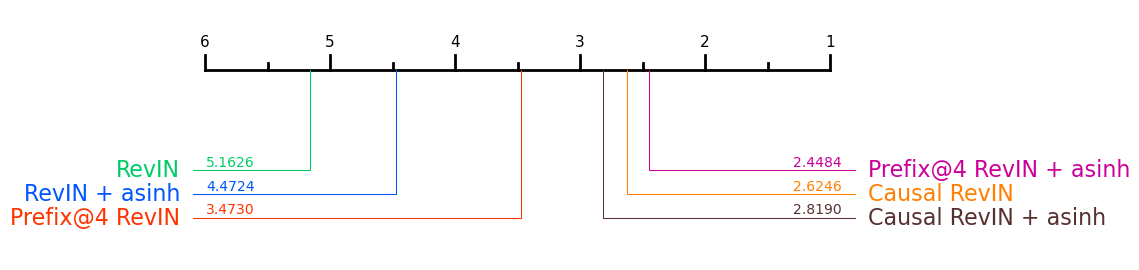

In [8]:
# Create Critical Difference plot for MAE
df_mae = pd.DataFrame(new_df_mae)
methods = df_mae.columns
plot = plot_critical_difference(df_mae.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True, highlight=dic_model_colors)

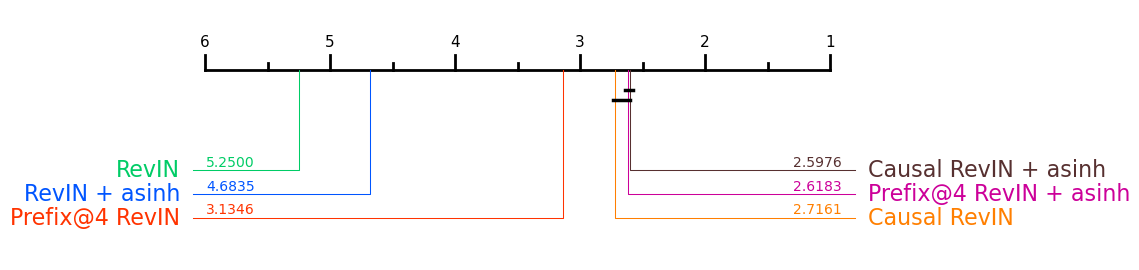

In [9]:
# Create Critical Difference plot for RMSE
df_mse = pd.DataFrame(new_df_mse)
methods = df_mse.columns
plot = plot_critical_difference(df_mse.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True, highlight=dic_model_colors)

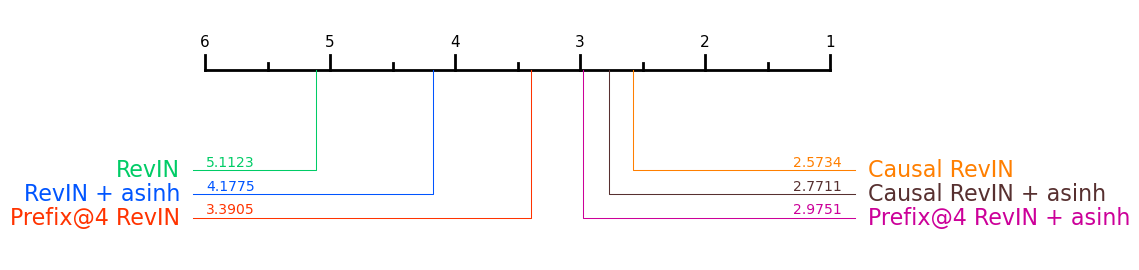

In [10]:
# Create Critical Difference plot for MASE
df_mase = pd.DataFrame(new_df_mase)
methods = df_mase.columns
plot = plot_critical_difference(df_mase.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True, highlight=dic_model_colors)

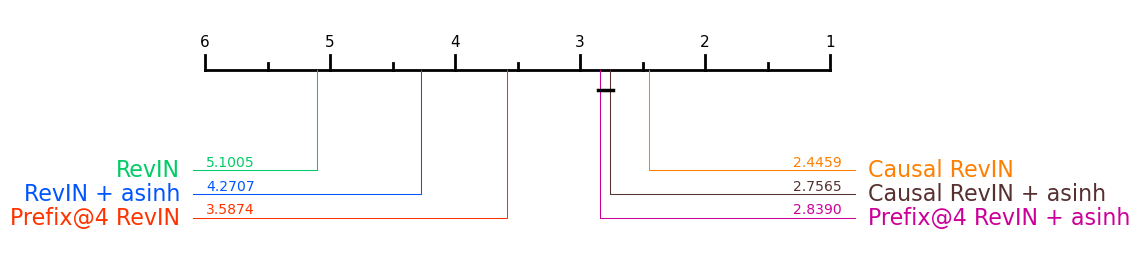

In [11]:
# Create Critical Difference plot for SQL
df_sql = pd.DataFrame(new_df_sql)
methods = df_sql.columns
plot = plot_critical_difference(df_sql.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True, highlight=dic_model_colors)

In [12]:
SIZE_KEYS = sorted(set(int(e.split("_")[1]) for e in MODEL_METRICS[next(iter(MODEL_METRICS))]["GIFT-Eval"].keys()))

ranks_per_size = {m: {s: {} for s in SIZE_KEYS} for m in METRIC_KEYS}
for metric in METRIC_KEYS:
    subdf = {size:{} for size in SIZE_KEYS}
    for model_name in MODEL_METRICS.keys():
        for key, value in MODEL_METRICS[model_name]["GIFT-Eval"].items():
            m, size = key.split("_", 1)
            m = m.lower()
            if m != metric:
                continue
            size = int(size)
            subdf[size][model_name] = value
    for size, data in subdf.items():
        df = pd.DataFrame(data)
        ranks = df.rank(axis=1, method='average', ascending=True)
        ranks_per_size[metric][size] = ranks.mean().to_dict()

## Evolution of ranks with forecast horizon

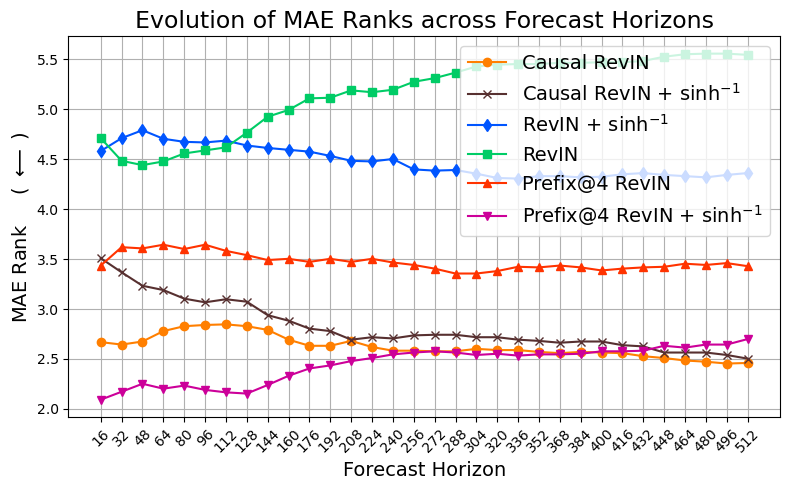

In [13]:
# MAE PLOT

plt.figure(figsize=FIGSIZE)
for model_name in MODEL_METRICS.keys():
    curr_model_ranks = [ranks_per_size["mae"][size][model_name] for size in SIZE_KEYS]
    plt.plot(curr_model_ranks, marker=dic_model_symbols[model_name], label=model_name.replace('asinh', "$\sinh^{-1}$"), color=dic_model_colors[model_name])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(SIZE_KEYS)), SIZE_KEYS, rotation=45)
plt.title("Evolution of MAE Ranks across Forecast Horizons", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MAE Rank     ( $\longleftarrow$ )", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'figures/plots/mae_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

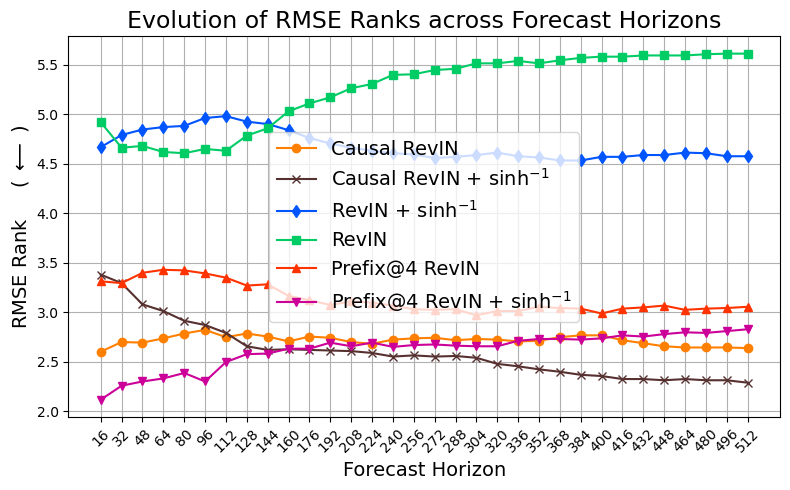

In [14]:
# RMSE PLOT

plt.figure(figsize=FIGSIZE)
for model_name in MODEL_METRICS.keys():
    curr_model_ranks = [ranks_per_size["rmse"][size][model_name] for size in SIZE_KEYS]
    plt.plot(curr_model_ranks, marker=dic_model_symbols[model_name], label=model_name.replace('asinh', "$\sinh^{-1}$"), color=dic_model_colors[model_name])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(SIZE_KEYS)), SIZE_KEYS, rotation=45)
plt.title("Evolution of RMSE Ranks across Forecast Horizons", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("RMSE Rank     ( $\longleftarrow$ )", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'figures/plots/rmse_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

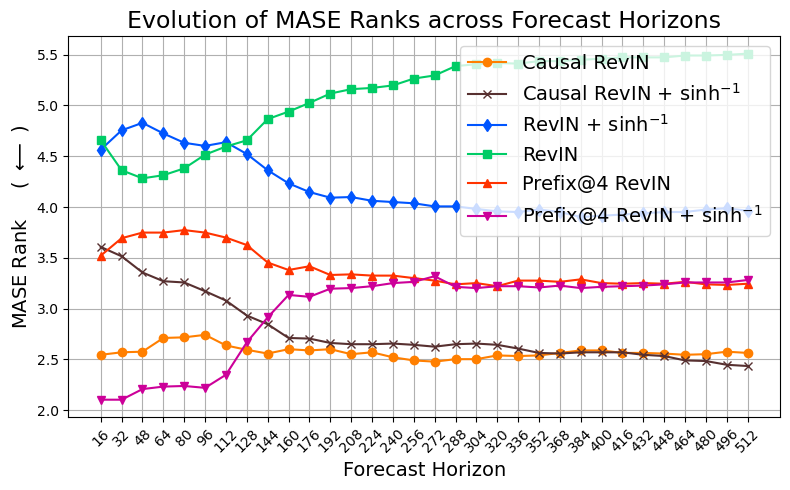

In [15]:
# MASE PLOT

plt.figure(figsize=FIGSIZE)
for model_name in MODEL_METRICS.keys():
    curr_model_ranks = [ranks_per_size["mase"][size][model_name] for size in SIZE_KEYS]
    plt.plot(curr_model_ranks, marker=dic_model_symbols[model_name], label=model_name.replace('asinh', "$\sinh^{-1}$"), color=dic_model_colors[model_name])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(SIZE_KEYS)), SIZE_KEYS, rotation=45)
plt.title("Evolution of MASE Ranks across Forecast Horizons", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MASE Rank     ( $\longleftarrow$ )", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'figures/plots/mase_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

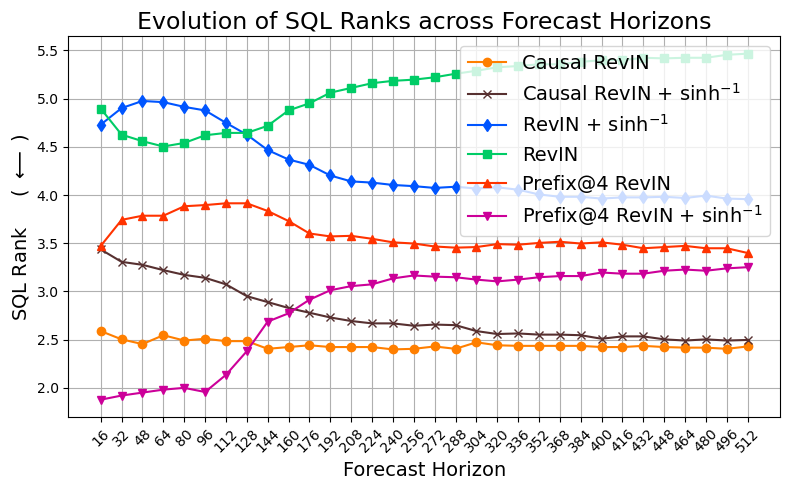

In [16]:
# SQL PLOT

plt.figure(figsize=FIGSIZE)
for model_name in MODEL_METRICS.keys():
    curr_model_ranks = [ranks_per_size["sql"][size][model_name] for size in SIZE_KEYS]
    plt.plot(curr_model_ranks, marker=dic_model_symbols[model_name], label=model_name.replace('asinh', "$\sinh^{-1}$"), color=dic_model_colors[model_name])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(SIZE_KEYS)), SIZE_KEYS, rotation=45)
plt.title("Evolution of SQL Ranks across Forecast Horizons", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("SQL Rank     ( $\longleftarrow$ )", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'figures/plots/sql_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()